In [10]:
%pip install --upgrade wordcloud pillow

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
     |████████████████████████████████| 6.6 MB 20.4 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [11]:
# Import necessary libraries

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from PIL import Image, ImageDraw

In [12]:
# Download required NLTK resources

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /home/ebe9e15f-7df6-49ac-91c8-df4a443c60f6/nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/ebe9e15f-7df6-49ac-91c8-df4a443c60f6/nltk_data..
[nltk_data]     .
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/ebe9e15f-7df6-49ac-91c8-df4a443c60f6/nltk_data..
[nltk_data]     .
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
# Unique Student Hobbies Dataset

text = """
photography photography photography photography photography
travelling travelling travelling travelling travelling
sketching sketching sketching sketching
cricket cricket cricket cricket
gardening gardening gardening
cycling cycling cycling
chess chess chess
journaling journaling journaling
stargazing stargazing stargazing
cooking cooking cooking
calligraphy calligraphy
birdwatching birdwatching
coding coding
filmmaking filmmaking
astronomy astronomy
trekking trekking
poetry poetry
baking baking
painting painting
drawing drawing
guitar guitar
singing singing
dancing dancing
swimming swimming
camping camping
hiking hiking
running running
meditation meditation
yoga yoga
podcasting podcasting
blogging blogging
vlogging vlogging
reading reading
writing writing
storytelling storytelling
travel travel
nature nature
wildlife wildlife
fishing fishing
badminton badminton
volleyball volleyball
football football
tabletennis tabletennis
carrom carrom

"""

print(text)


photography photography photography photography photography
travelling travelling travelling travelling travelling
sketching sketching sketching sketching
cricket cricket cricket cricket
gardening gardening gardening
cycling cycling cycling
chess chess chess
journaling journaling journaling
stargazing stargazing stargazing
cooking cooking cooking
calligraphy calligraphy
birdwatching birdwatching
coding coding
filmmaking filmmaking
astronomy astronomy
trekking trekking
poetry poetry
baking baking
painting painting
drawing drawing
guitar guitar
singing singing
dancing dancing
swimming swimming
camping camping
hiking hiking
running running
meditation meditation
yoga yoga
podcasting podcasting
blogging blogging
vlogging vlogging
reading reading
writing writing
storytelling storytelling
travel travel
nature nature
wildlife wildlife
fishing fishing
badminton badminton
volleyball volleyball
football football
tabletennis tabletennis
carrom carrom




In [14]:
# Convert text into individual words

words = word_tokenize(text.lower())

print("Total words:", len(words))
print(words[:50])

# Remove common English stopwords

stop_words = set(stopwords.words('english'))

filtered_words = [
    word for word in words
    if word.isalpha() and word not in stop_words
]

print("\nFiltered words:")
print(filtered_words[:50])

Total words: 104
['photography', 'photography', 'photography', 'photography', 'photography', 'travelling', 'travelling', 'travelling', 'travelling', 'travelling', 'sketching', 'sketching', 'sketching', 'sketching', 'cricket', 'cricket', 'cricket', 'cricket', 'gardening', 'gardening', 'gardening', 'cycling', 'cycling', 'cycling', 'chess', 'chess', 'chess', 'journaling', 'journaling', 'journaling', 'stargazing', 'stargazing', 'stargazing', 'cooking', 'cooking', 'cooking', 'calligraphy', 'calligraphy', 'birdwatching', 'birdwatching', 'coding', 'coding', 'filmmaking', 'filmmaking', 'astronomy', 'astronomy', 'trekking', 'trekking', 'poetry', 'poetry']

Filtered words:
['photography', 'photography', 'photography', 'photography', 'photography', 'travelling', 'travelling', 'travelling', 'travelling', 'travelling', 'sketching', 'sketching', 'sketching', 'sketching', 'cricket', 'cricket', 'cricket', 'cricket', 'gardening', 'gardening', 'gardening', 'cycling', 'cycling', 'cycling', 'chess', 'ches

In [15]:
# Count the frequency of each hobby

word_freq = Counter(filtered_words)

print("Hobby Frequencies:\n")

for hobby, frequency in word_freq.most_common():
    print(f"{hobby}: {frequency}")

Hobby Frequencies:

photography: 5
travelling: 5
sketching: 4
cricket: 4
gardening: 3
cycling: 3
chess: 3
journaling: 3
stargazing: 3
cooking: 3
calligraphy: 2
birdwatching: 2
coding: 2
filmmaking: 2
astronomy: 2
trekking: 2
poetry: 2
baking: 2
painting: 2
drawing: 2
guitar: 2
singing: 2
dancing: 2
swimming: 2
camping: 2
hiking: 2
running: 2
meditation: 2
yoga: 2
podcasting: 2
blogging: 2
vlogging: 2
reading: 2
writing: 2
storytelling: 2
travel: 2
nature: 2
wildlife: 2
fishing: 2
badminton: 2
volleyball: 2
football: 2
tabletennis: 2
carrom: 2


Word Frequency:
Counter({'photography': 2, 'moments': 2, 'memories': 2, 'favorite': 1, 'hobby': 1, 'love': 1, 'capturing': 1, 'beautiful': 1, 'nature': 1, 'landscapes': 1, 'portraits': 1, 'helps': 1, 'explore': 1, 'creativity': 1, 'technology': 1, 'different': 1, 'perspectives': 1, 'enjoy': 1, 'taking': 1, 'photos': 1, 'special': 1, 'events': 1, 'everyday': 1, 'powerful': 1, 'way': 1, 'tell': 1, 'stories': 1, 'capture': 1})
Using font:
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf


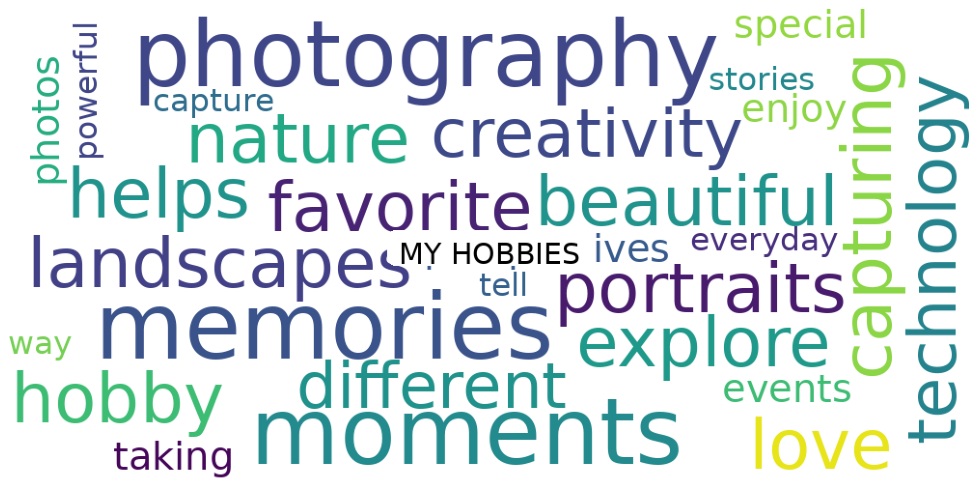

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import ImageDraw, ImageFont
from collections import Counter
import re
import matplotlib.font_manager as fm

# --------------------------------------------------
# TEXT
# --------------------------------------------------
text = """
Photography is my favorite hobby. I love capturing beautiful moments,
nature, landscapes, portraits and memories. Photography helps me explore
creativity, technology and different perspectives. I enjoy taking photos
during special events and everyday moments. It is a powerful way to tell
stories and capture memories.
"""

# --------------------------------------------------
# CREATE WORD LIST
# --------------------------------------------------
words = re.findall(r'\b[a-zA-Z]+\b', text.lower())

stop_words = {
    "the", "is", "a", "an", "and", "of", "to", "in",
    "my", "me", "i", "it", "for", "on", "with", "this",
    "that", "are", "be", "as", "during"
}

filtered_words = [
    word for word in words
    if word not in stop_words
]

# --------------------------------------------------
# WORD FREQUENCY
# --------------------------------------------------
word_freq = Counter(filtered_words)

print("Word Frequency:")
print(word_freq)

# --------------------------------------------------
# FIND A VALID FONT AUTOMATICALLY
# --------------------------------------------------
font_path = fm.findfont("DejaVu Sans")

print("Using font:")
print(font_path)

# --------------------------------------------------
# CREATE WORD CLOUD
# --------------------------------------------------
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis",
    max_words=80,
    min_font_size=8,
    max_font_size=95,
    margin=3,
    prefer_horizontal=0.9,
    relative_scaling=0.5,
    collocations=False,
    random_state=25,
    font_path=font_path
).generate_from_frequencies(word_freq)

# --------------------------------------------------
# CONVERT TO IMAGE
# --------------------------------------------------
wc_image = wordcloud.to_image().convert("RGB")

# --------------------------------------------------
# ADD HEADING
# --------------------------------------------------
draw = ImageDraw.Draw(wc_image)

heading_font = ImageFont.truetype(font_path, 30)

heading = "MY HOBBIES"

bbox = draw.textbbox(
    (0, 0),
    heading,
    font=heading_font
)

text_width = bbox[2] - bbox[0]
text_height = bbox[3] - bbox[1]

x = (1000 - text_width) // 2
y = (500 - text_height) // 2

# White box behind heading
draw.rounded_rectangle(
    (
        x - 12,
        y - 7,
        x + text_width + 12,
        y + text_height + 7
    ),
    radius=8,
    fill="white"
)

# Heading
draw.text(
    (x, y),
    heading,
    fill="black",
    font=heading_font
)

# --------------------------------------------------
# DISPLAY
# --------------------------------------------------
plt.figure(figsize=(15, 7))
plt.imshow(wc_image)
plt.axis("off")
plt.tight_layout()
plt.show()